# Classical time series analysis
This notebook tracks my efforts to find a competitive classical time series model that can serve as a benchmark against which I'd like to compare my quantum reservoir computing model.

Loading data from file
(1788336, 26)


(array([1575000., 1600000., 1625000., 1650000., 1675000., 1700000.,
        1725000., 1750000., 1775000., 1800000.]),
 [Text(1575000.0, 0, '1.575'),
  Text(1600000.0, 0, '1.600'),
  Text(1625000.0, 0, '1.625'),
  Text(1650000.0, 0, '1.650'),
  Text(1675000.0, 0, '1.675'),
  Text(1700000.0, 0, '1.700'),
  Text(1725000.0, 0, '1.725'),
  Text(1750000.0, 0, '1.750'),
  Text(1775000.0, 0, '1.775'),
  Text(1800000.0, 0, '1.800')])

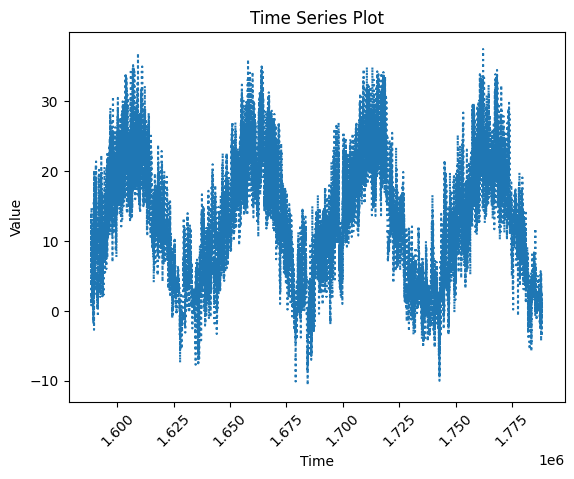

In [6]:
import os.path

from src.data.loading.configs import MODEL_DIR_CLASSICAL
# ---- load data ----
from src.data.loading.geosphere import Geosphere

data = Geosphere().load_data_into_memory()

print(data.shape)

historically_relevant_data = data[-200000:]

import matplotlib.pyplot as plt

plt.plot(historically_relevant_data.index, historically_relevant_data['tl'], linestyle = 'dotted')

# Add title and axis labels
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.xticks(rotation=45)

In [7]:
# ---- select data ----

import pandas as pd

selected_columns = [
    'cglo'
    , 'chim'
    , 'dd'
    , 'ddx'
    , 'ff'
#    , 'ffam_flag'
    , 'ffx'
    , 'p'
#    , 'pred'
    , 'rf'
    , 'rr'
    , 'rrm'
    , 'sh'
    , 'so'
    , 'tb10'
    , 'tb20'
    , 'tb50'
    , 'tl'
    , 'tlmax'
    , 'tlmin'
    , 'ts'
    , 'tsmax'
    , 'tsmin'
    , 'zeitx'
    , 'timestamps'
#    , 'stationId'
]

usable_data = historically_relevant_data.dropna(axis="columns", how="all")

final_data_columns = usable_data.columns.intersection(selected_columns)

final_data = historically_relevant_data[final_data_columns].reset_index(drop=True)
final_data.set_index(pd.to_datetime(final_data['timestamps'], format="ISO8601"))
final_data.index.freq = '10min'

# output
print("Selected columns: {}".format(selected_columns))
print("Usable columns: {}".format(usable_data.columns))
print("Realised columns: {}".format(final_data_columns))
print("Final data dimensions: {}".format(final_data.shape))

Selected columns: ['cglo', 'chim', 'dd', 'ddx', 'ff', 'ffx', 'p', 'rf', 'rr', 'rrm', 'sh', 'so', 'tb10', 'tb20', 'tb50', 'tl', 'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx', 'timestamps']
Usable columns: Index(['cglo', 'dd', 'ddx', 'ff', 'ffam_flag', 'ffx', 'p', 'pred', 'rf', 'rr',
       'rrm', 'so', 'tl', 'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx',
       'timestamps', 'stationId'],
      dtype='object')
Realised columns: Index(['cglo', 'dd', 'ddx', 'ff', 'ffx', 'p', 'rf', 'rr', 'rrm', 'so', 'tl',
       'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx', 'timestamps'],
      dtype='object')
Final data dimensions: (200000, 18)


In [ ]:
import pickle
# ---- model selection ----

# parameters of the time-series:
# - one-dimensional
# - value 'tl'

# tried but failed due to conflicting dependencies:
# Seshadri, Ram (2020). GitHub - AutoViML/Auto_TS: enables you to build and deploy multiple time
# series models using ML and statistical techniques with a single line of code.
# Source code: https://github.com/AutoViML/Auto_TS

# instead used:
import pmdarima as pm

# reload/select best model
file = MODEL_DIR_CLASSICAL / 'arima_model.pkl'

if os.path.exists(file):    # load
    classical_model = pickle.load(open(file, "rb"))
else:   # select best model according to the data and fits model to data
    classical_model = pm.auto_arima(final_data['tl'],
                        seasonal=True,
                        m=144, # 144 Intervalle à 10min = 24 Stunden Saison
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)
    # dump arima model to avoid recalculation
    with open(file, 'wb') as pkl:
        pickle.dump(classical_model, pkl)

print("The type of the model is: {}".format(type(classical_model)))
print("Its parameters are: {}".format(classical_model))

In [37]:
# ---- model prediction ----
#MM: to be continued
forecast, conf_int = classical_model.predict(n_periods=50, return_conf_int=True)

print("Forecast: {}".format(forecast))
print("Conf int: {}".format(conf_int))



Forecast: 200    0.375898
201    0.326010
202    0.313230
203    0.226235
204    0.176347
         ...   
295   -4.177891
296   -4.227779
297   -4.166344
298   -4.290447
299   -4.377442
Length: 100, dtype: float64
Conf int: [[  0.0783633    0.67343179]
 [ -0.11948247   0.77150228]
 [ -0.26307493   0.88953427]
 [ -0.47507394   0.92754319]
 [ -0.64821356   1.00090753]
 [ -0.82150829   1.07442698]
 [ -1.07019979   1.07491357]
 [ -1.24645617   1.15139467]
 [ -1.46196398   1.19291238]
 [ -1.67984324   1.23680154]
 [ -1.90023662   1.28320483]
 [ -2.04901735   1.4064251 ]
 [ -2.23755939   1.49519185]
 [ -2.46588979   1.54953216]
 [ -2.69691114   1.60656342]
 [ -2.85640669   1.74049849]
 [ -3.09279572   1.80289743]
 [ -3.29473974   1.90506617]
 [ -3.49932574   2.00987689]
 [ -3.74363782   2.08019888]
 [ -3.95343588   2.19022166]
 [ -4.20290819   2.26570387]
 [ -4.41781259   2.38083299]
 [ -4.63522876   2.49847388]
 [ -4.92934364   2.54438385]
 [ -5.11459241   2.70407215]
 [ -5.33937714   2.829

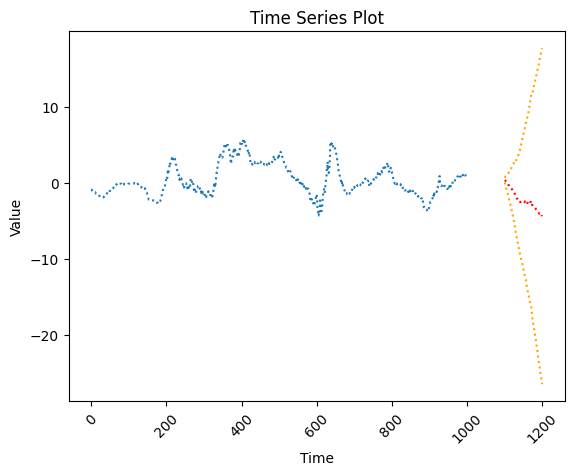

In [45]:
# plot time-series and prediction

plt.plot(final_data.index, final_data['tl'], linestyle = 'dotted')
plt.plot(final_data['tl'].size + forecast.index - len(forecast), forecast, linestyle = 'dotted', color='red')
plt.plot(final_data['tl'].size + forecast.index - len(forecast), conf_int, linestyle = 'dotted', color='orange')

# Add title and axis labels
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.xticks(rotation=45)

# Display the plot
plt.show()